In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd -q {_repo_root[0]}
del _repo_root

# Criteo scaling

Validation-selected test performance under repeated-shuffle Adam/SparseAdam training. The plots separate per-feature parameter-width comparison, preprocessing comparison, and dimension scaling. Lower is better.

## Setup

In [2]:
import matplotlib as mpl
import pandas as pd

from paper.experiments.criteo_scaling import (
    PROFILES,
    default_raw_path,
    select_evaluations,
    summarize_evaluations,
    validate_raw,
)
from paper.plotting import (
    plot_criteo_models_by_dimension,
    plot_criteo_fm_dimensions,
    plot_criteo_spectral_comparison,
    plot_criteo_spectral_dimensions,
)

mpl.rcParams["figure.dpi"] = 200

In [3]:
profile_name = "full"
profile = PROFILES[profile_name]
raw_path = default_raw_path(profile_name)
metric = "logloss"

## Load and validate results

Preprocessing is fitted once on a fixed 10% sample of the training pool. Each data seed defines a deterministic stream of fresh permutations over that fixed pool, and `train_size` counts cumulative optimizer examples rather than distinct rows. The explicit profile `train_sizes` are the only evaluation checkpoints and their maximum is the final budget; the stream creates as many permutations as that budget requires. Learning rates are selected independently at each checkpoint using validation loss; test metrics are then reported only for the selected checkpoint trajectories.

In [4]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; run paper.experiments.criteo_scaling first"
    )
print(raw_path)

raw = pd.read_csv(raw_path)
validate_raw(raw, profile)

selected = select_evaluations(raw)
summary = summarize_evaluations(selected)
summary[[
    "train_size",
    "model",
    "dim",
    "selected_lr",
    "median_test_logloss",
    "median_test_brier",
    "n",
]].sort_values(["train_size", "dim", "model"])

notebooks/runs/criteo_scaling_full_repeated_shuffle.csv


,train_size,model,dim,selected_lr,median_test_logloss,median_test_brier,n
27,4096,linear-bucketed,0,0.026827,0.565729,0.189298,24
36,4096,linear-continuous,0,0.051795,0.550226,0.183721,24
0,4096,fm,3,0.013895,0.641727,0.224426,24
45,4096,spectral-bucketed,3,0.100000,0.598976,0.203363,24
72,4096,spectral-continuous,3,0.013895,0.597788,0.203812,24
...,...,...,...,...,...,...,...
62,268435456,spectral-bucketed,7,0.001000,0.454384,0.147372,24
89,268435456,spectral-continuous,7,0.001000,0.455030,0.147627,24
26,268435456,fm,11,0.001000,0.475857,0.154199,24
71,268435456,spectral-bucketed,11,0.001000,0.456269,0.147874,24


## All models within each dimension

Each facet compares Linear (bucketed), Linear (continuous), FM, Spectral (bucketed), and Spectral (continuous). FM rank is matched to the spectral matrix parameter width per encoded feature; bucketed and continuous numerical preprocessing have different vocabulary sizes, so their total parameter counts are not equal. The two dimensionless linear curves are repeated for reference.

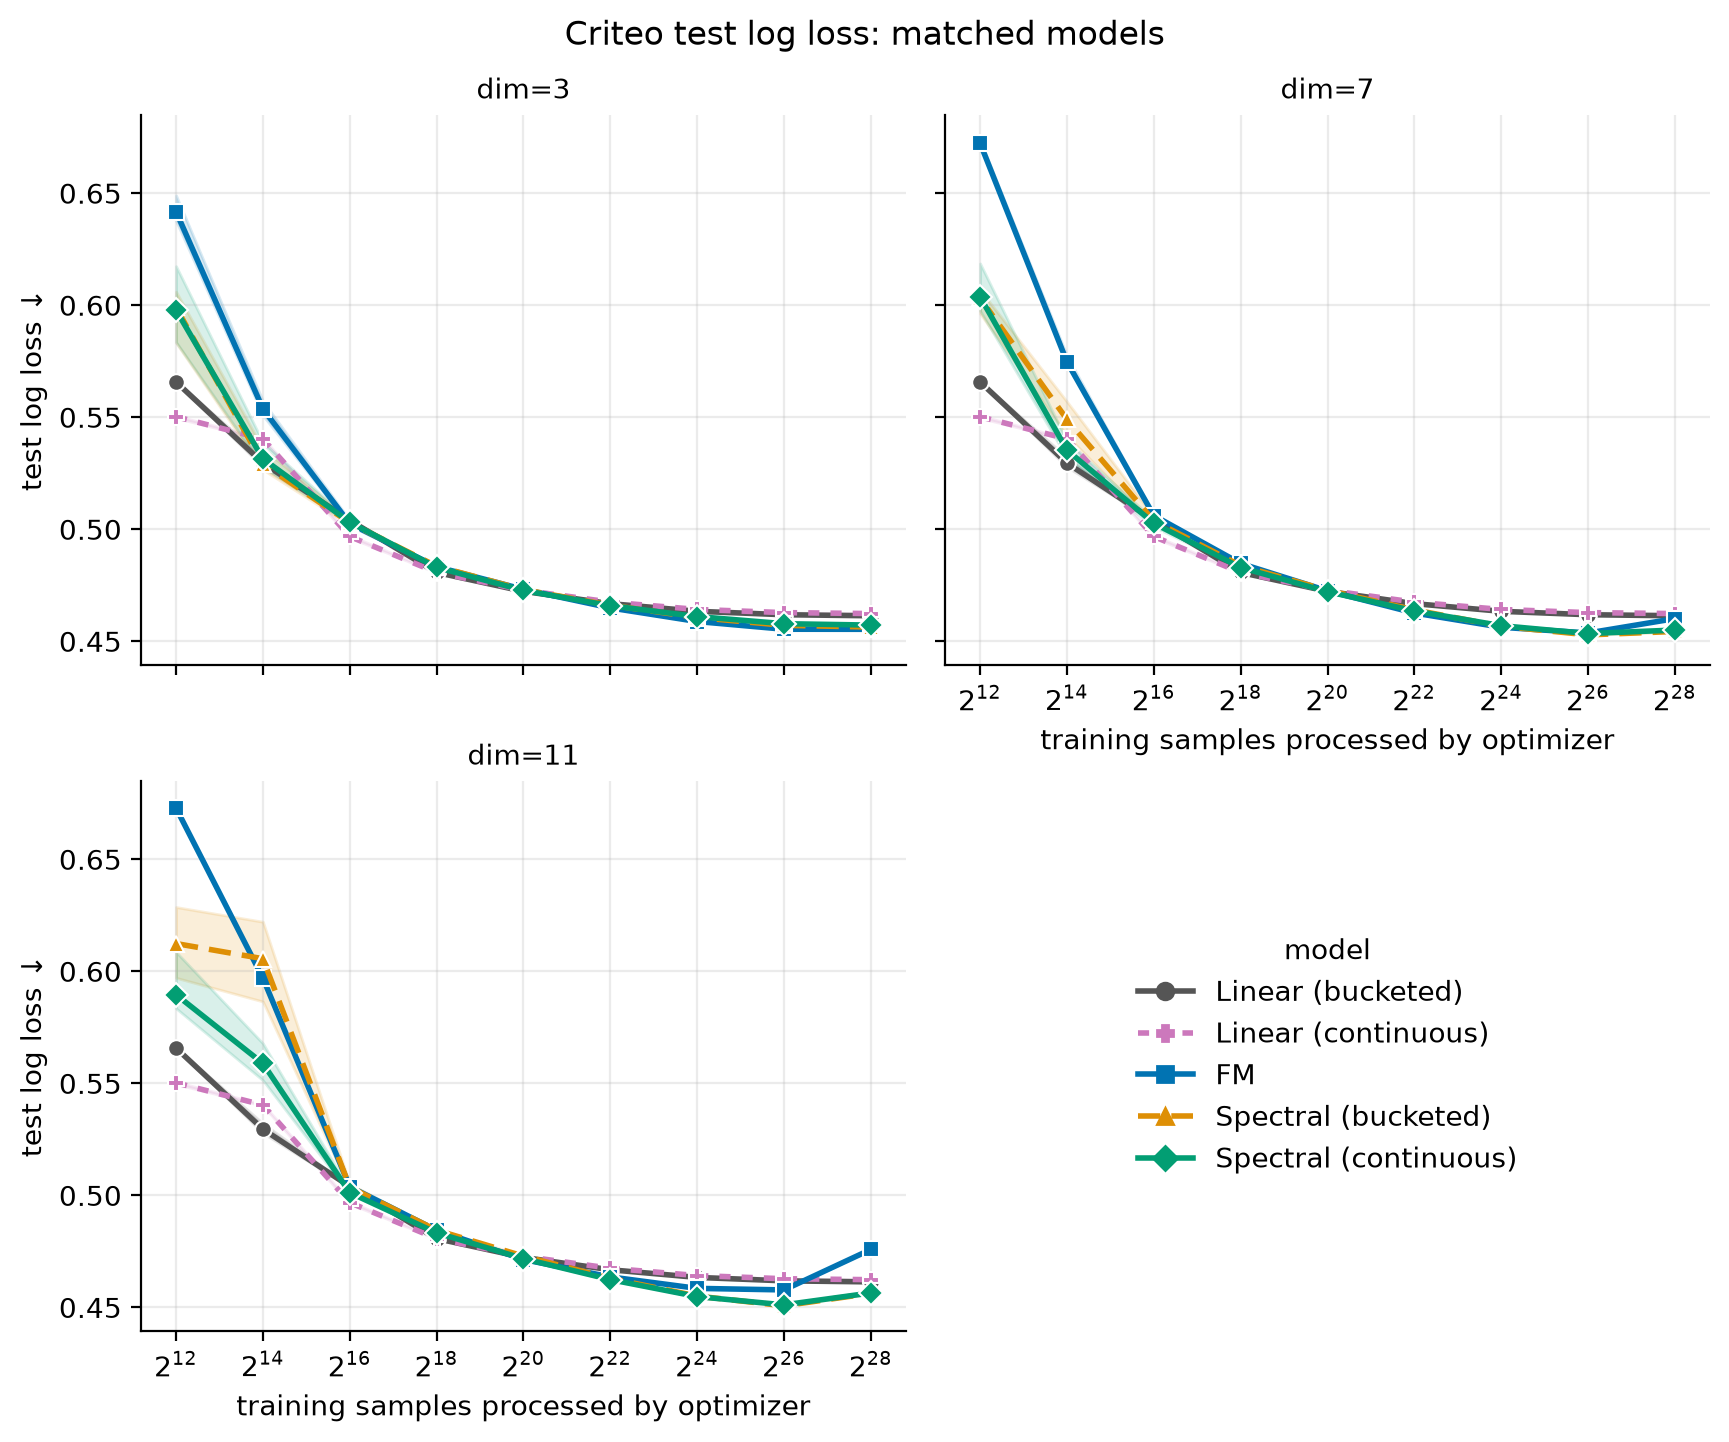

In [5]:
plot_criteo_models_by_dimension(summary, metric=metric);

## Spectral preprocessing within each dimension

This view removes the linear and FM references to isolate the effect of the numerical representation.

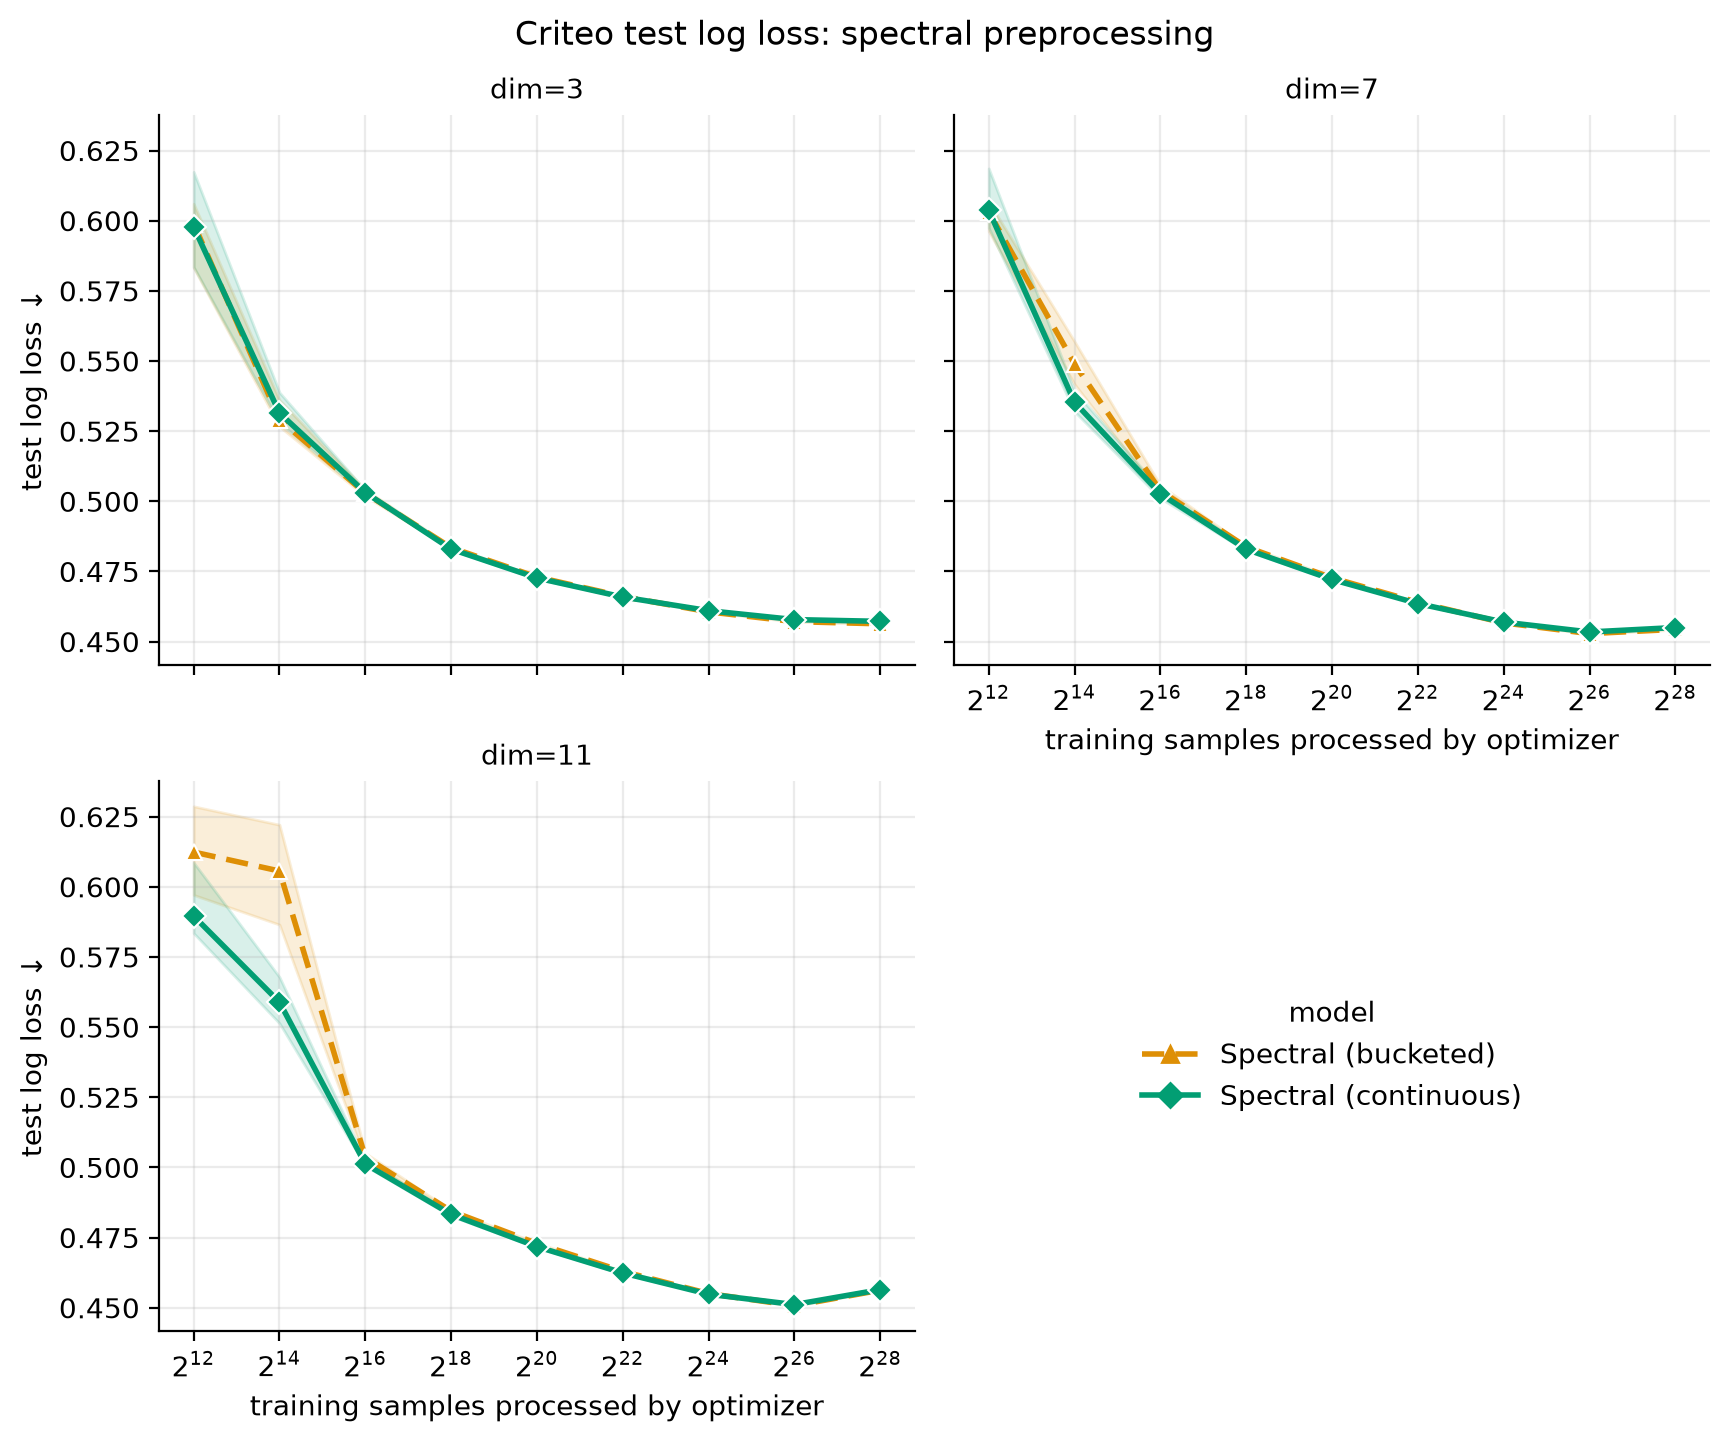

In [6]:
plot_criteo_spectral_comparison(summary, metric=metric);

## Spectral (continuous) across dimensions

All spectral capacities using continuous numerical preprocessing on one axis.

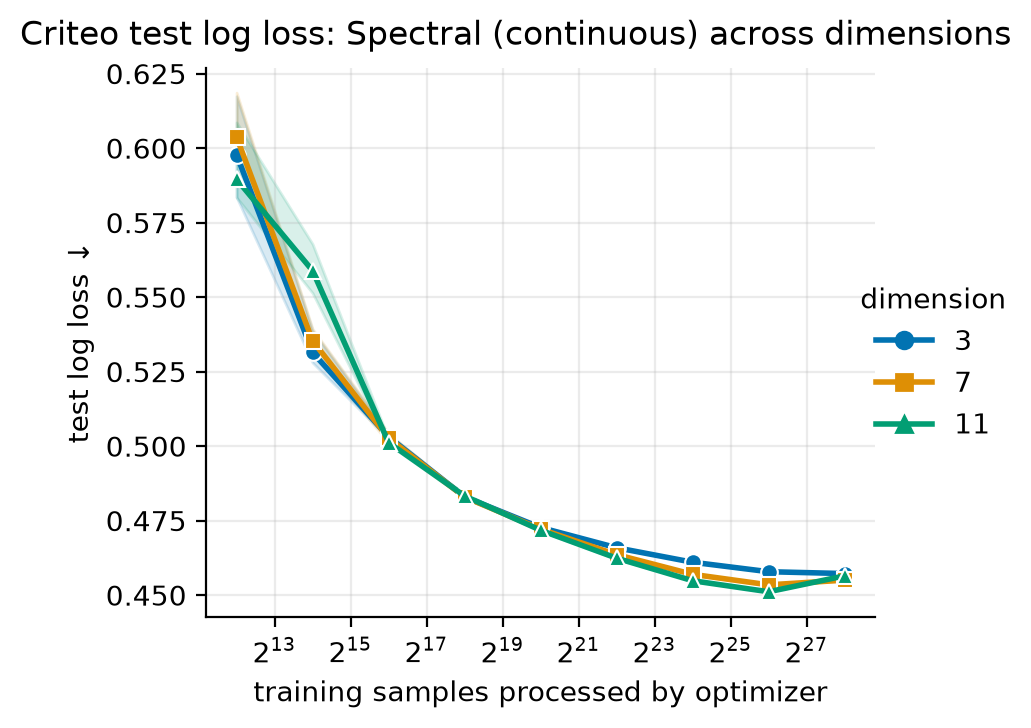

In [7]:
plot_criteo_spectral_dimensions(
    summary, "spectral-continuous", metric=metric
);

### Spectral (continuous) detail from $2^{21}$ to $2^{28}$

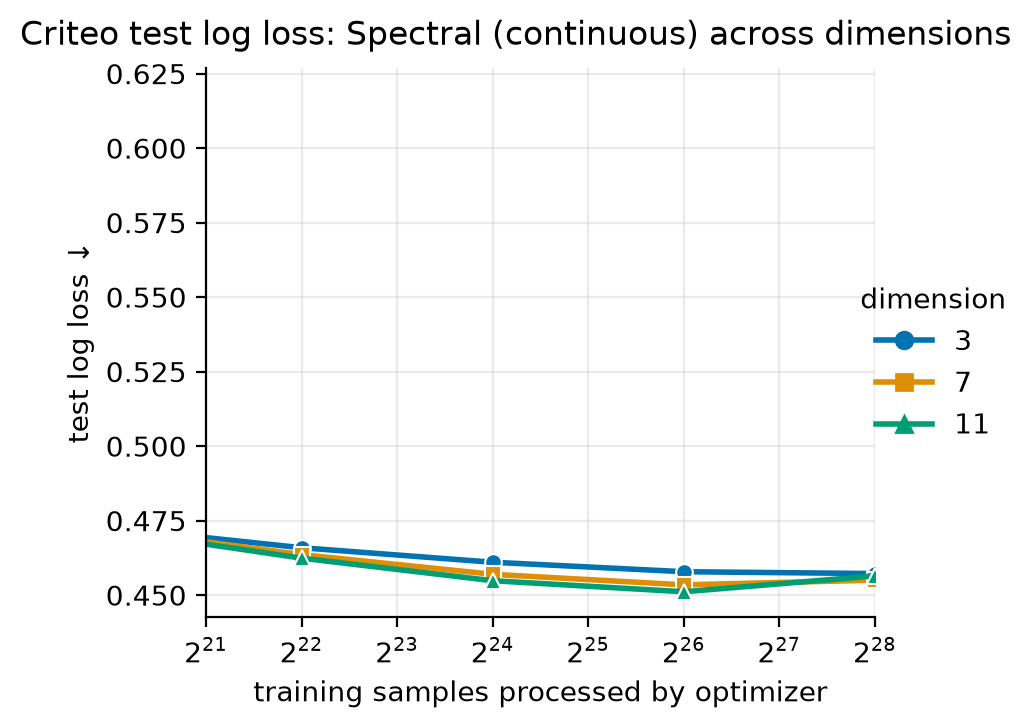

In [8]:
plot_criteo_spectral_dimensions(
    summary,
    "spectral-continuous",
    metric=metric,
    xlim=(2**21, 2**28),
);

## FM across embedding dimensions

Compare the per-feature-width-matched FM embedding ranks across the full scaling range.

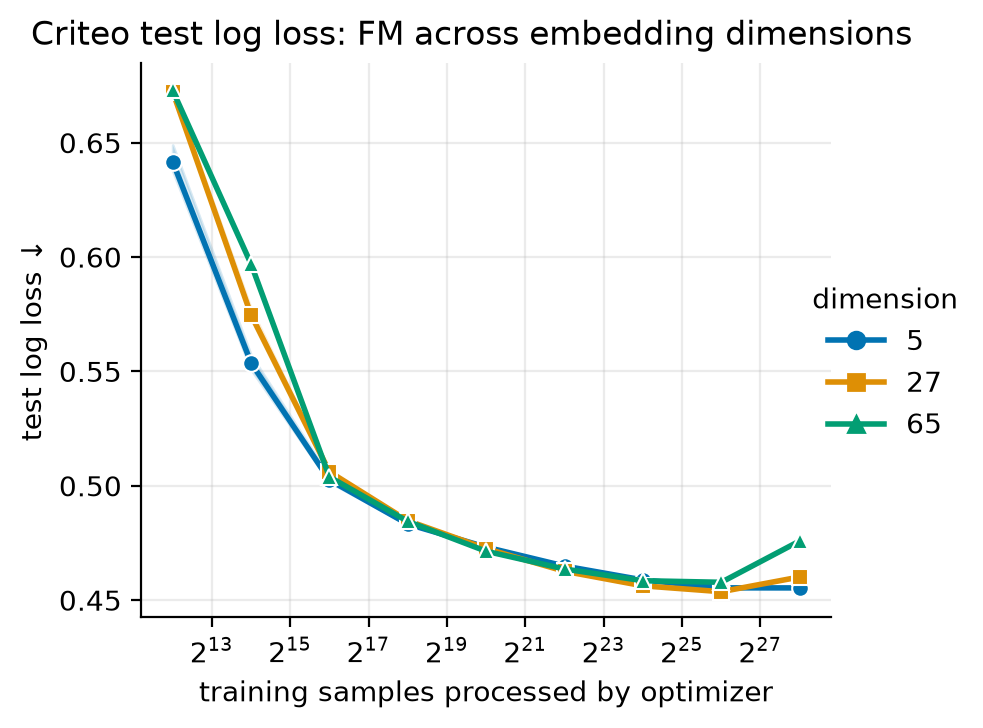

In [9]:
plot_criteo_fm_dimensions(summary, metric=metric);

## Spectral (bucketed) across dimensions

All spectral capacities using bucketed numerical preprocessing on one axis.

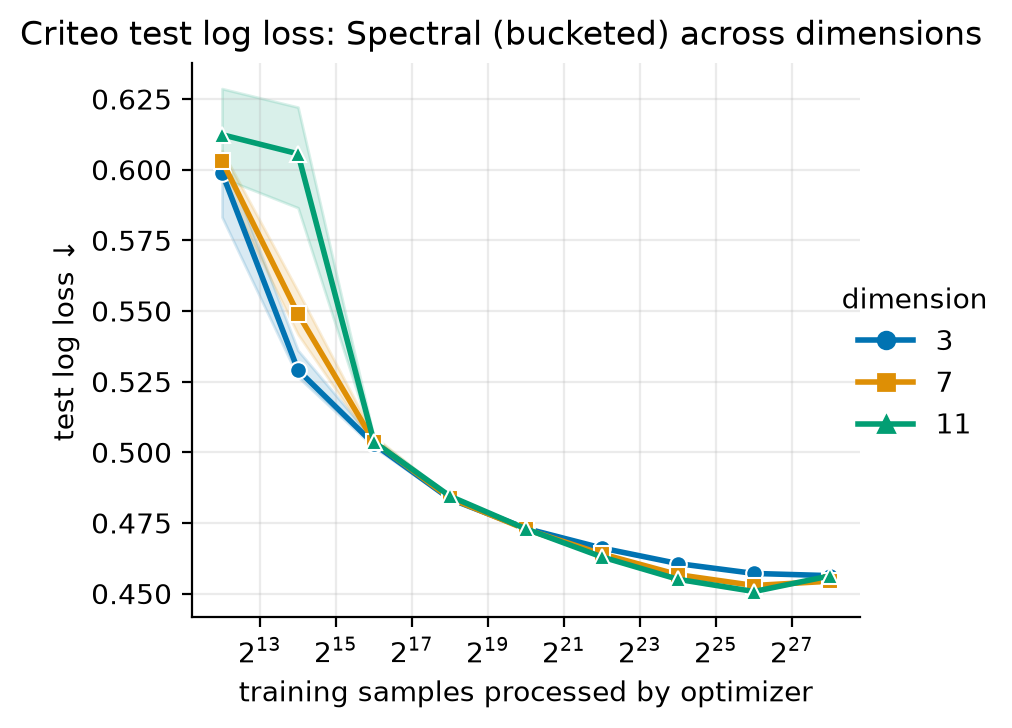

In [10]:
plot_criteo_spectral_dimensions(
    summary, "spectral-bucketed", metric=metric
);

## Reading the comparison

The first two figures hold dimension fixed, so bucketed and continuous spectral neurons have the same matrix width per encoded feature; their different preprocessing vocabularies can still produce different total parameter counts. The spectral dimension views hold preprocessing fixed, while the FM view varies embedding rank. Lines are medians across retraining runs and bands span the 25th to 75th percentiles.

The full profile evaluates only its requested powers of two through $2^{28}$ and stops there. The training-pool size determines how many fresh deterministic permutations are needed for each data seed, but pass boundaries do not add evaluation checkpoints or change the budget. Batches are formed over the concatenated stream, so a batch may cross a pass boundary.

These are fixed-representation examples-seen curves: preprocessing and model size stay fixed while optimizer exposure grows, and rows repeat after the first pass. They are not end-to-end dataset-size scaling curves. Change `metric` in Setup to `"brier"` for the corresponding Brier-score views.